<a href="https://colab.research.google.com/github/sahilshirsat2004-coder/CSL701-CE45_Machine-Learning-Lab/blob/main/Copy_of_ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# This is formatted as code
```

Student Name :Sahil Ganesh Shirsat

Batch : CE3


Roll Number : CE45



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [2]:
# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Upload data.csv manually in Colab
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv("data.csv")

# Display first 5 rows
df.head()

Saving data.csv to data.csv


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

Dataset Shape: (569, 33)

Column Names:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Data Types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean    

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



Diagnosis Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


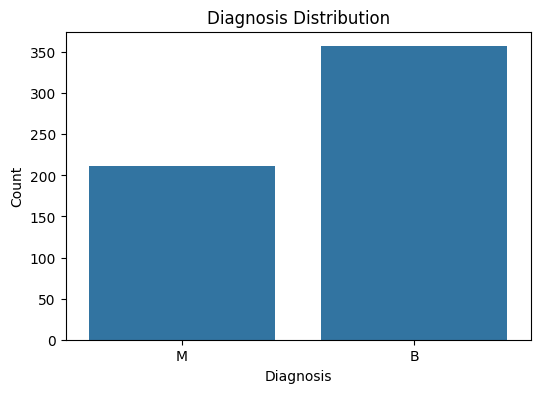

In [3]:
# Task 2: Explore the Dataset

# Dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
display(df.describe())

# Diagnosis distribution
print("\nDiagnosis Distribution:")
print(df["diagnosis"].value_counts())

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="diagnosis", data=df)
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [4]:
# Task 3: Data Cleaning and Feature/Target Selection

# Drop unnecessary columns
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

# Convert diagnosis:
# M = 1 (Malignant)
# B = 0 (Benign)
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Separate features and target
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nNumber of Features:", X.shape[1])
print("Target Classes:")
print(y.value_counts())

Feature Shape: (569, 30)
Target Shape: (569,)

Number of Features: 30
Target Classes:
diagnosis
0    357
1    212
Name: count, dtype: int64


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [5]:
# Task 4: Standardize Features

scaler = StandardScaler()

# Standardize all 30 features
X_scaled = scaler.fit_transform(X)

print("Original Shape:", X.shape)
print("Scaled Shape:", X_scaled.shape)

# Check mean and standard deviation
print("\nMean of scaled features:")
print(X_scaled.mean(axis=0))

print("\nStandard deviation of scaled features:")
print(X_scaled.std(axis=0))

Original Shape: (569, 30)
Scaled Shape: (569, 30)

Mean of scaled features:
[-1.37363271e-16  6.86816353e-17 -1.24875700e-16 -2.18532476e-16
 -8.36667193e-16  1.87313551e-16  4.99502802e-17 -4.99502802e-17
  1.74825981e-16  4.74527662e-16  2.37263831e-16 -1.12388130e-16
 -1.12388130e-16 -1.31119486e-16 -1.52972733e-16  1.74825981e-16
  1.62338411e-16  0.00000000e+00  8.74129903e-17 -6.24378502e-18
 -8.24179623e-16  1.24875700e-17 -3.74627101e-16  0.00000000e+00
 -2.37263831e-16 -3.37164391e-16  7.49254203e-17  2.24776261e-16
  2.62238971e-16 -5.74428222e-16]

Standard deviation of scaled features:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [6]:
# Task 5: Implement PCA

# Create PCA with 2 components
pca = PCA(n_components=2)

# Transform the standardized data
X_pca = pca.fit_transform(X_scaled)

print("Original Data Shape:", X_scaled.shape)
print("PCA Data Shape:", X_pca.shape)

# Create DataFrame for PCA results
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

# Add diagnosis
pca_df["Diagnosis"] = y.values

display(pca_df.head())

Original Data Shape: (569, 30)
PCA Data Shape: (569, 2)


,PC1,PC2,Diagnosis
0,9.192837,1.948583,1
1,2.387802,-3.768172,1
2,5.733896,-1.075174,1
3,7.122953,10.275589,1
4,3.935302,-1.948072,1


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


Variance explained by PC1: 0.44272025607526366
Variance explained by PC2: 0.18971182044033078

Cumulative variance retained by PC1 + PC2: 0.6324320765155944

PC1 Variance: 44.27%
PC2 Variance: 18.97%
Total Variance Retained: 63.24%


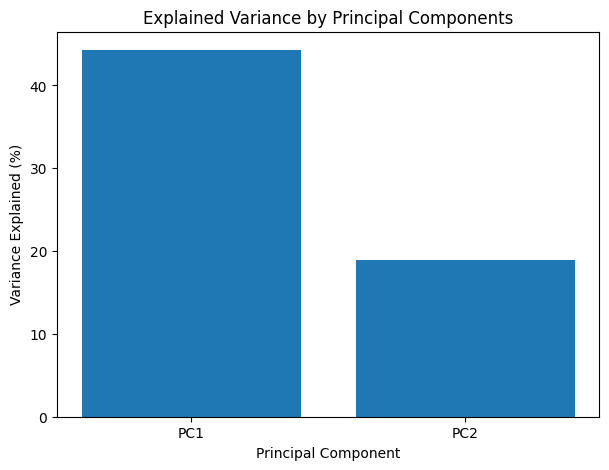

In [8]:
# Task 6: Explained Variance Ratio

# Variance explained by each principal component
explained_variance = pca.explained_variance_ratio_

print("Variance explained by PC1:",
      explained_variance[0])

print("Variance explained by PC2:",
      explained_variance[1])

# Cumulative variance
cumulative_variance = explained_variance.sum()

print("\nCumulative variance retained by PC1 + PC2:",
      cumulative_variance)

# Convert to percentage
print("\nPC1 Variance: {:.2f}%".format(
    explained_variance[0] * 100
))

print("PC2 Variance: {:.2f}%".format(
    explained_variance[1] * 100
))

print("Total Variance Retained: {:.2f}%".format(
    cumulative_variance * 100
))


# Plot explained variance

components = ["PC1", "PC2"]

plt.figure(figsize=(7, 5))
plt.bar(components, explained_variance * 100)

plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")

plt.show()

# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

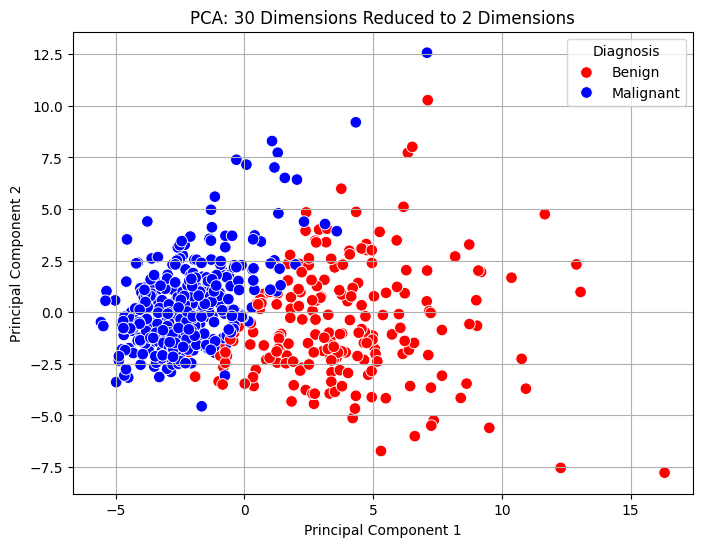

In [9]:
# Task 7: PCA 2D Scatter Plot

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    data=pca_df,
    palette={0: "blue", 1: "red"},
    s=70
)

plt.title("PCA: 30 Dimensions Reduced to 2 Dimensions")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    title="Diagnosis",
    labels=["Benign", "Malignant"]
)

plt.grid(True)
plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [10]:
# Task 8: Train Logistic Regression on Original 30 Features

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
lr_raw = LogisticRegression(max_iter=1000)

# Train model
lr_raw.fit(X_train, y_train)

# Predict test data
y_pred_raw = lr_raw.predict(X_test)

# Calculate accuracy
accuracy_raw = accuracy_score(y_test, y_pred_raw)

print("Logistic Regression using 30 Features")
print("Accuracy:", accuracy_raw)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_raw,
    target_names=["Benign", "Malignant"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_raw))

Logistic Regression using 30 Features
Accuracy: 0.9649122807017544

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Confusion Matrix:
[[71  1]
 [ 3 39]]


# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [11]:
# Task 9: Train Logistic Regression using PCA Data

# Split PCA data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
lr_pca = LogisticRegression(max_iter=1000)

# Train model
lr_pca.fit(X_train_pca, y_train_pca)

# Predict
y_pred_pca = lr_pca.predict(X_test_pca)

# Calculate accuracy
accuracy_pca = accuracy_score(
    y_test_pca,
    y_pred_pca
)

print("Logistic Regression using 2 PCA Features")
print("Accuracy:", accuracy_pca)

print("\nClassification Report:")
print(classification_report(
    y_test_pca,
    y_pred_pca,
    target_names=["Benign", "Malignant"]
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_test_pca,
    y_pred_pca
))

Logistic Regression using 2 PCA Features
Accuracy: 0.9385964912280702

Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

Confusion Matrix:
[[71  1]
 [ 6 36]]


# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



MODEL PERFORMANCE COMPARISON

Accuracy using 30 Original Features: 0.9649122807017544
Accuracy using 2 PCA Features: 0.9385964912280702

Accuracy Difference: 0.02631578947368418


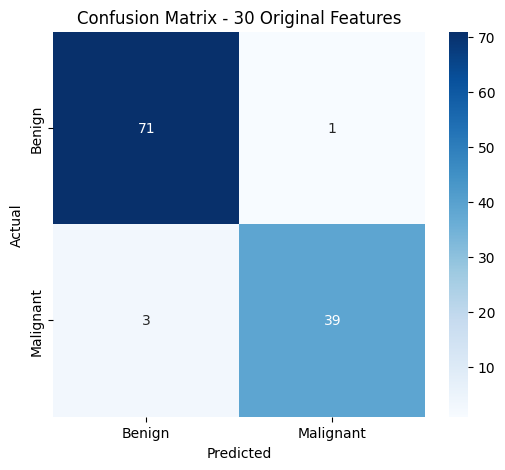

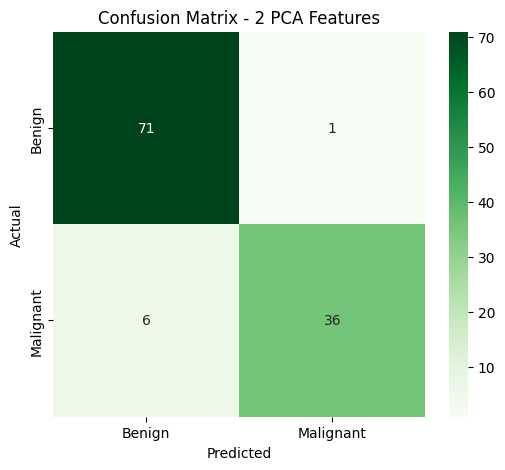

Classification Report - 30 Original Features
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Classification Report - 2 PCA Features
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



,Model,Number of Features,Accuracy
0,Logistic Regression - 30 Features,30,0.964912
1,Logistic Regression - 2 PCA Features,2,0.938596


In [12]:
# Task 10: Compare Performance Before and After PCA

print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

print("\nAccuracy using 30 Original Features:",
      accuracy_raw)

print("Accuracy using 2 PCA Features:",
      accuracy_pca)

print("\nAccuracy Difference:",
      accuracy_raw - accuracy_pca)

# Confusion matrices
cm_raw = confusion_matrix(y_test, y_pred_raw)
cm_pca = confusion_matrix(y_test_pca, y_pred_pca)

# Plot raw data confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_raw,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Confusion Matrix - 30 Original Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot PCA confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_pca,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Confusion Matrix - 2 PCA Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report - Original Data

print("Classification Report - 30 Original Features")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred_raw,
    target_names=["Benign", "Malignant"]
))


# Classification Report - PCA Data

print("\nClassification Report - 2 PCA Features")
print("=" * 50)

print(classification_report(
    y_test_pca,
    y_pred_pca,
    target_names=["Benign", "Malignant"]
))

# Create comparison table

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression - 30 Features",
        "Logistic Regression - 2 PCA Features"
    ],
    "Number of Features": [
        30,
        2
    ],
    "Accuracy": [
        accuracy_raw,
        accuracy_pca
    ]
})

display(comparison)

# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.